In [7]:
from pathlib import Path
import numpy as np
import random

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

import timm

In [8]:
candidates = [
    Path('train_data'),
    Path('../train_data'),
    Path.cwd() / 'train_data',
    Path.cwd().parent / 'train_data',
]
train_data_dir = next((p.resolve() for p in candidates if p.exists()), None)
if train_data_dir is None:
    raise FileNotFoundError(
        "Could not find 'train_data' folder. Tried: " + ", ".join(str(p) for p in candidates)
    )
print('Using train_data:', train_data_dir)

seed = 42
TRAIN_FRAC = 0.90  # train uses only 90% of images

# Pretrained ImageNet backbones (including DenseNet121) expect ImageNet normalization
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

dataset = datasets.ImageFolder(root=str(train_data_dir), transform=transform)
num_classes = len(dataset.classes)
print('Num classes:', num_classes)

# Deterministic 90/10 split (disjoint)
n_all = len(dataset)
k_train = int(round(TRAIN_FRAC * n_all))
k_train = max(1, min(k_train, n_all - 1))  # ensure at least 1 train and 1 test

g = torch.Generator().manual_seed(seed)
perm = torch.randperm(n_all, generator=g)
train_idx = perm[:k_train].tolist()
test_idx = perm[k_train:].tolist()

train_img = Subset(dataset, train_idx)
test_img = Subset(dataset, test_idx)

batch_size = 32
num_workers = 4

g_loader = torch.Generator().manual_seed(seed)
train_loader = DataLoader(
    train_img,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    generator=g_loader,
 )
test_loader = DataLoader(
    test_img,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    generator=g_loader,
 )

print('Total images:', n_all)
print(f"Train images: {len(train_img)} ({len(train_img)/n_all:.0%})")
print(f"Test images:  {len(test_img)} ({len(test_img)/n_all:.0%})")
print('Classes (folder order used for labels):')
for i, name in enumerate(dataset.classes):
    print(f'  {i}: {name}')


Using train_data: /content/train_data
Num classes: 30
Total images: 6993
Train images: 6294 (90%)
Test images:  699 (10%)
Classes (folder order used for labels):
  0: Airport
  1: BareLand
  2: BaseballField
  3: Beach
  4: Bridge
  5: Center
  6: Church
  7: Commercial
  8: DenseResidential
  9: Desert
  10: Farmland
  11: Forest
  12: Industrial
  13: Meadow
  14: MediumResidential
  15: Mountain
  16: Park
  17: Parking
  18: Playground
  19: Pond
  20: Port
  21: RailwayStation
  22: Resort
  23: River
  24: School
  25: SparseResidential
  26: Square
  27: Stadium
  28: StorageTanks
  29: Viaduct


In [9]:
# Fine-tuning strategy comparison (fixed hyperparameters)
# Strategies:
#  1) Linear probe
#  2) Last block fine-tuning
#  3) Full fine-tuning of the entire backbone
#  4) Selective layer unfreezing (<= 20% of backbone parameters)

from dataclasses import dataclass
import math

seed = globals().get("seed", 42)


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(seed)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")


# ---------------------------
# Fixed hyperparameters
# ---------------------------
EPOCHS = 8
LR = 1e-3
WEIGHT_DECAY = 1e-4
OPTIMIZER_NAME = "adamw"

GRAD_NORM_EVERY = 10  # log gradient norm stats every N batches


def _is_head_param(name: str) -> bool:
    return name.startswith("fc.")


def _param_group_from_name(name: str) -> str:
    if name.startswith("fc."):
        return "head"
    if name.startswith("layer4."):
        return "layer4"
    if name.startswith("layer3."):
        return "layer3"
    if name.startswith("layer2."):
        return "layer2"
    if name.startswith("layer1."):
        return "layer1"
    return "stem"


def count_trainable_params(model: nn.Module) -> int:
    return int(sum(p.numel() for p in model.parameters() if p.requires_grad))


def backbone_named_parameters(model: nn.Module):
    for n, p in model.named_parameters():
        if not _is_head_param(n):
            yield n, p


def head_named_parameters(model: nn.Module):
    for n, p in model.named_parameters():
        if _is_head_param(n):
            yield n, p


def freeze_backbone(model: nn.Module) -> None:
    for _, p in backbone_named_parameters(model):
        p.requires_grad = False


def unfreeze_backbone(model: nn.Module) -> None:
    for _, p in backbone_named_parameters(model):
        p.requires_grad = True


def unfreeze_head(model: nn.Module) -> None:
    for _, p in head_named_parameters(model):
        p.requires_grad = True


def _set_bn_eval_for_frozen_params(model: nn.Module) -> None:
    for m in model.modules():
        if isinstance(m, nn.BatchNorm2d):
            bn_params = list(m.parameters(recurse=False))
            if bn_params and all(not p.requires_grad for p in bn_params):
                m.eval()


def build_resnet50(num_classes: int, seed_for_head_init: int = 42) -> nn.Module:
    # timm pretrained weights only
    set_seed(seed_for_head_init)
    model = timm.create_model("resnet50", pretrained=True)

    # deterministic classifier head init
    set_seed(seed_for_head_init)
    model.reset_classifier(num_classes)

    model.to(device)
    model.train()
    return model


@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader) -> tuple[float, float]:
    model.eval()
    correct = 0
    total = 0
    loss_sum = 0.0
    criterion = nn.CrossEntropyLoss()

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        loss_sum += float(loss.item()) * x.size(0)
        pred = logits.argmax(dim=1)
        correct += int((pred == y).sum().item())
        total += int(y.numel())

    return loss_sum / max(1, total), correct / max(1, total)


def make_optimizer(model: nn.Module) -> torch.optim.Optimizer:
    params = [p for p in model.parameters() if p.requires_grad]
    if OPTIMIZER_NAME.lower() == "adamw":
        return torch.optim.AdamW(params, lr=LR, weight_decay=WEIGHT_DECAY)
    if OPTIMIZER_NAME.lower() == "sgd":
        return torch.optim.SGD(params, lr=LR, momentum=0.9, weight_decay=WEIGHT_DECAY)
    raise ValueError(f"Unknown OPTIMIZER_NAME={OPTIMIZER_NAME}")


def _depth_score(param_name: str) -> tuple:
    layer_rank = 0
    block_rank = -1

    if param_name.startswith("layer1."):
        layer_rank = 1
    elif param_name.startswith("layer2."):
        layer_rank = 2
    elif param_name.startswith("layer3."):
        layer_rank = 3
    elif param_name.startswith("layer4."):
        layer_rank = 4

    parts = param_name.split(".")
    if len(parts) >= 2 and parts[0].startswith("layer") and parts[1].isdigit():
        block_rank = int(parts[1])

    sub_rank = 0
    if ".conv3." in param_name or ".bn3." in param_name:
        sub_rank = 3
    elif ".conv2." in param_name or ".bn2." in param_name:
        sub_rank = 2
    elif ".conv1." in param_name or ".bn1." in param_name:
        sub_rank = 1

    return (layer_rank, block_rank, sub_rank)


def selective_unfreeze_backbone_20pct(model: nn.Module, fraction: float = 0.20) -> dict:
    # Rationale: We unfreeze the deepest backbone layers first (layer4 -> layer3 -> ...)
    # under a strict parameter budget (20% of total backbone params).
    # Deep layers encode high-level semantic features most relevant for transfer learning.
    # Shallow layers capture low-level edges/textures that are largely dataset-agnostic.
    # By prioritising deep layers we maximise task-specific adaptation per parameter updated.
    freeze_backbone(model)
    unfreeze_head(model)

    backbone_params = [(n, p) for n, p in model.named_parameters() if not _is_head_param(n)]
    total_backbone = sum(p.numel() for _, p in backbone_params)
    cap = int(total_backbone * fraction)

    backbone_params_sorted = sorted(backbone_params, key=lambda np_: _depth_score(np_[0]), reverse=True)

    selected_numel = 0
    selected_names: list[str] = []

    for n, p in backbone_params_sorted:
        n_el = p.numel()
        if selected_numel + n_el <= cap:
            p.requires_grad = True
            selected_numel += n_el
            selected_names.append(n)

    by_layer = {"layer4": 0, "layer3": 0, "layer2": 0, "layer1": 0, "stem": 0}
    for n in selected_names:
        if n.startswith("layer4."):
            by_layer["layer4"] += 1
        elif n.startswith("layer3."):
            by_layer["layer3"] += 1
        elif n.startswith("layer2."):
            by_layer["layer2"] += 1
        elif n.startswith("layer1."):
            by_layer["layer1"] += 1
        else:
            by_layer["stem"] += 1

    rationale = (
        "Selective 20% strategy: Deepest backbone layers unfrozen first (layer4→layer3→…). "
        "Deep layers learn high-level, task-specific semantics that need adapting; "
        "shallow layers capture universal low-level features (edges, textures) that transfer "
        "unchanged. This maximises task-relevant adaptation within the 20% parameter budget."
    )
    return {
        "cap_params": cap,
        "selected_backbone_params": selected_numel,
        "selected_backbone_fraction": selected_numel / max(1, total_backbone),
        "total_backbone_params": total_backbone,
        "selected_param_tensors": len(selected_names),
        "by_layer_tensors": by_layer,
        "rationale": rationale,
    }


def compute_trainable_backbone_stats(model: nn.Module) -> tuple[int, int, float]:
    bb_all = [(n, p) for n, p in backbone_named_parameters(model)]
    bb_trainable = [(n, p) for n, p in bb_all if p.requires_grad]
    total = sum(p.numel() for _, p in bb_all)
    trainable = sum(p.numel() for _, p in bb_trainable)
    return int(trainable), int(total), float(trainable / max(1, total))


def configure_strategy(model: nn.Module, strategy: str) -> None:
    strategy = strategy.lower().strip()

    if strategy == "linear_probe":
        freeze_backbone(model)
        unfreeze_head(model)
        return

    if strategy == "last_block":
        freeze_backbone(model)
        unfreeze_head(model)
        for p in model.layer4.parameters():
            p.requires_grad = True
        return

    if strategy == "full_finetune":
        unfreeze_backbone(model)
        unfreeze_head(model)
        return

    if strategy == "selective_20pct":
        info = selective_unfreeze_backbone_20pct(model, fraction=0.20)
        print("\n[Selective 20% Layer Unfreezing — Rationale]")
        print(info["rationale"])
        print(f"  Budget cap  : {info['cap_params']:,} params")
        print(f"  Unfrozen BB : {info['selected_backbone_params']:,} params "
              f"({info['selected_backbone_fraction']*100:.2f}% of backbone)")
        print(f"  By layer    : {info['by_layer_tensors']}")
        return

    raise ValueError(f"Unknown strategy: {strategy}")


def compute_group_grad_norms(model: nn.Module) -> dict[str, float]:
    sumsq: dict[str, float] = {"stem": 0.0, "layer1": 0.0, "layer2": 0.0, "layer3": 0.0, "layer4": 0.0, "head": 0.0}
    for n, p in model.named_parameters():
        if p.grad is None or (not p.requires_grad):
            continue
        g = p.grad.detach()
        if g.is_sparse:
            g = g.to_dense()
        g = g.float()
        group = _param_group_from_name(n)
        sumsq[group] += float((g * g).sum().item())
    return {k: math.sqrt(v) for k, v in sumsq.items()}


def _summarize_grad_samples(samples_by_group: dict[str, list[float]]) -> dict[str, dict[str, float]]:
    out: dict[str, dict[str, float]] = {}
    for group, vals in samples_by_group.items():
        if not vals:
            out[group] = {"mean": 0.0, "std": 0.0, "max": 0.0, "n": 0}
            continue
        arr = np.asarray(vals, dtype=np.float64)
        out[group] = {"mean": float(arr.mean()), "std": float(arr.std(ddof=0)), "max": float(arr.max()), "n": int(arr.size)}
    return out


def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    grad_every: int = GRAD_NORM_EVERY,
) -> tuple[float, float, dict[str, dict[str, float]]]:
    model.train()
    _set_bn_eval_for_frozen_params(model)

    criterion = nn.CrossEntropyLoss()

    correct = 0
    total = 0
    loss_sum = 0.0

    grad_samples: dict[str, list[float]] = {"stem": [], "layer1": [], "layer2": [], "layer3": [], "layer4": [], "head": []}

    for step, (x, y) in enumerate(loader):
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()

        if grad_every > 0 and (step % grad_every == 0):
            gnorms = compute_group_grad_norms(model)
            for k, v in gnorms.items():
                grad_samples[k].append(v)

        optimizer.step()

        loss_sum += float(loss.item()) * x.size(0)
        pred = logits.argmax(dim=1)
        correct += int((pred == y).sum().item())
        total += int(y.numel())

    return loss_sum / max(1, total), correct / max(1, total), _summarize_grad_samples(grad_samples)


@dataclass
class StrategyHistory:
    strategy: str
    percent_backbone_unfrozen: float
    train_loss: list[float]
    train_acc: list[float]
    val_loss: list[float]
    val_acc: list[float]
    grad_norm_stats_by_epoch: list[dict[str, dict[str, float]]]


def run_strategy(strategy: str) -> StrategyHistory:
    model = build_resnet50(num_classes=num_classes, seed_for_head_init=seed)
    configure_strategy(model, strategy=strategy)

    _, _, frac = compute_trainable_backbone_stats(model)
    optimizer = make_optimizer(model)

    train_loss_hist: list[float] = []
    train_acc_hist: list[float] = []
    val_loss_hist: list[float] = []
    val_acc_hist: list[float] = []
    grad_stats_epochs: list[dict[str, dict[str, float]]] = []

    for _epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc, grad_stats = train_one_epoch(model, train_loader, optimizer)
        va_loss, va_acc = evaluate(model, test_loader)

        train_loss_hist.append(float(tr_loss))
        train_acc_hist.append(float(tr_acc))
        val_loss_hist.append(float(va_loss))
        val_acc_hist.append(float(va_acc))
        grad_stats_epochs.append(grad_stats)

    if device.type == "cuda":
        torch.cuda.empty_cache()

    return StrategyHistory(
        strategy=strategy,
        percent_backbone_unfrozen=100.0 * float(frac),
        train_loss=train_loss_hist,
        train_acc=train_acc_hist,
        val_loss=val_loss_hist,
        val_acc=val_acc_hist,
        grad_norm_stats_by_epoch=grad_stats_epochs,
    )


strategies = ["linear_probe", "last_block", "full_finetune", "selective_20pct"]
FT_HISTORIES: list[StrategyHistory] = [run_strategy(s) for s in strategies]


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]


[Selective 20% Layer Unfreezing — Rationale]
Selective 20% strategy: Deepest backbone layers unfrozen first (layer4→layer3→…). Deep layers learn high-level, task-specific semantics that need adapting; shallow layers capture universal low-level features (edges, textures) that transfer unchanged. This maximises task-relevant adaptation within the 20% parameter budget.
  Budget cap  : 4,701,606 params
  Unfrozen BB : 4,701,568 params (20.00% of backbone)
  By layer    : {'layer4': 23, 'layer3': 39, 'layer2': 23, 'layer1': 0, 'stem': 0}


Training and validation accuracy vs percentage of unfrozen parameters
  linear_probe | backbone unfrozen=  0.00% | train acc=0.9563 | val acc=0.9099
selective_20pct | backbone unfrozen= 20.00% | train acc=0.9908 | val acc=0.9256
    last_block | backbone unfrozen= 63.66% | train acc=0.9929 | val acc=0.9342
 full_finetune | backbone unfrozen=100.00% | train acc=0.9797 | val acc=0.9456


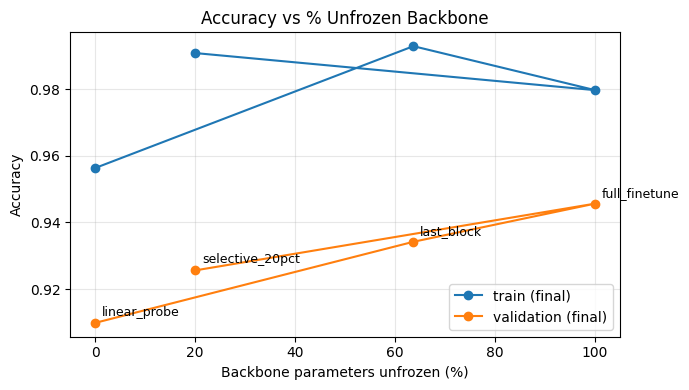


Gradient norm statistics across layers

linear_probe (backbone unfrozen=0.00%)
    stem | mean=0.0000e+00 | std=0.0000e+00 | max=0.0000e+00 | n=20
  layer1 | mean=0.0000e+00 | std=0.0000e+00 | max=0.0000e+00 | n=20
  layer2 | mean=0.0000e+00 | std=0.0000e+00 | max=0.0000e+00 | n=20
  layer3 | mean=0.0000e+00 | std=0.0000e+00 | max=0.0000e+00 | n=20
  layer4 | mean=0.0000e+00 | std=0.0000e+00 | max=0.0000e+00 | n=20
    head | mean=3.5323e-01 | std=8.2295e-02 | max=5.0609e-01 | n=20

last_block (backbone unfrozen=63.66%)
    stem | mean=0.0000e+00 | std=0.0000e+00 | max=0.0000e+00 | n=20
  layer1 | mean=0.0000e+00 | std=0.0000e+00 | max=0.0000e+00 | n=20
  layer2 | mean=0.0000e+00 | std=0.0000e+00 | max=0.0000e+00 | n=20
  layer3 | mean=0.0000e+00 | std=0.0000e+00 | max=0.0000e+00 | n=20
  layer4 | mean=2.1731e-01 | std=2.7243e-01 | max=1.0023e+00 | n=20
    head | mean=2.1604e-01 | std=2.5892e-01 | max=9.4074e-01 | n=20

full_finetune (backbone unfrozen=100.00%)
    stem | mean=3.6829

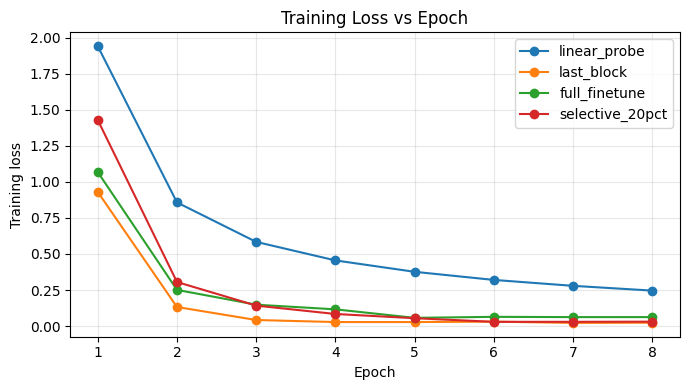

In [10]:
import matplotlib.pyplot as plt

# 1) Training and validation accuracy vs percentage of unfrozen parameters
xs = [h.percent_backbone_unfrozen for h in FT_HISTORIES]
final_train_acc = [h.train_acc[-1] for h in FT_HISTORIES]
final_val_acc = [h.val_acc[-1] for h in FT_HISTORIES]
labels = [h.strategy for h in FT_HISTORIES]

print("Training and validation accuracy vs percentage of unfrozen parameters")
for x, tr, va, lab in sorted(zip(xs, final_train_acc, final_val_acc, labels), key=lambda t: t[0]):
    print(f"{lab:>14} | backbone unfrozen={x:6.2f}% | train acc={tr:.4f} | val acc={va:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(xs, final_train_acc, "o-", label="train (final)")
plt.plot(xs, final_val_acc, "o-", label="validation (final)")
for x, y, lab in zip(xs, final_val_acc, labels):
    plt.annotate(lab, (x, y), textcoords="offset points", xytext=(5, 5), fontsize=9)
plt.xlabel("Backbone parameters unfrozen (%)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs % Unfrozen Backbone")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# 2) Gradient norm statistics across layers
print("\nGradient norm statistics across layers")
layer_groups = ["stem", "layer1", "layer2", "layer3", "layer4", "head"]
last_epoch_idx = EPOCHS - 1

for h in FT_HISTORIES:
    print(f"\n{h.strategy} (backbone unfrozen={h.percent_backbone_unfrozen:.2f}%)")
    stats = h.grad_norm_stats_by_epoch[last_epoch_idx]
    for g in layer_groups:
        s = stats.get(g, {"mean": 0.0, "std": 0.0, "max": 0.0, "n": 0})
        print(f"  {g:>6} | mean={s['mean']:.4e} | std={s['std']:.4e} | max={s['max']:.4e} | n={s['n']}")


# 3) Convergence stability comparison (training loss vs epoch)
print("\nConvergence stability comparison (training loss vs epoch)")
epochs = list(range(1, EPOCHS + 1))
plt.figure(figsize=(7, 4))
for h in FT_HISTORIES:
    plt.plot(epochs, h.train_loss, marker="o", label=h.strategy)
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Training Loss vs Epoch")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
